            Trading_Volume  Trading_money      open    min    max     close  \
date                                                                          
2015-05-22        0.120550     3229666392  0.049383  145.0  147.0  0.053697   
2015-05-25        0.086671     2396692046  0.050265  145.5  147.5  0.057218   
2015-05-26        0.085185     2368218823  0.053792  146.5  148.5  0.055458   
2015-05-27        0.133175     3536266849  0.048501  145.0  147.0  0.052817   
2015-05-28        0.206123     5388568653  0.051146  146.0  147.5  0.056338   

            spread  Trading_turnover  raw_close  signal_buy  signal_sell  
date                                                                      
2015-05-22     0.0              6813      145.5           0            1  
2015-05-25     2.0              5998      147.5           1            0  
2015-05-26    -1.0              6148      146.5           0            1  
2015-05-27    -1.5              6869      145.0           0            

/Users/qwer/files/developer/stock_proj/.venv/lib/python3.12/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 2.04e+03 |
|    ep_rew_mean     | -44.8    |
| time/              |          |
|    fps             | 2459     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 2.04e+03    |
|    ep_rew_mean          | -62.9       |
| time/                   |             |
|    fps                  | 1667        |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008704815 |
|    clip_fraction        | 0.0748      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -0.548      |
|    learning_rate        | 0.

Training complete. Model saved.


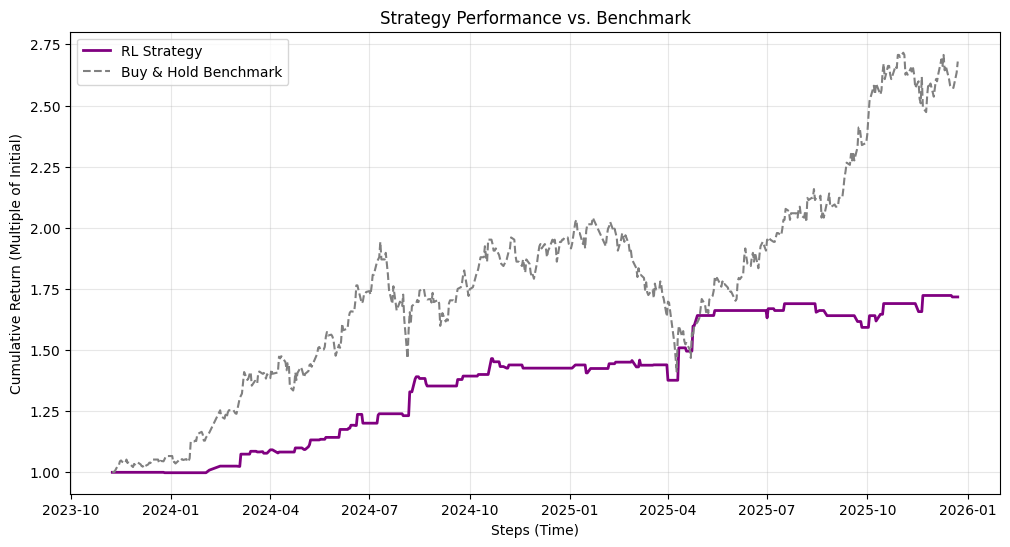

--- Performance Report ---
Total_Return: 0.7171
Sharpe_Ratio: 1.8716
Max_Drawdown: -0.0605


In [5]:
# Cell 1: Import modules and load/process data
import pandas as pd
import sys
import os

# Get the absolute path to the directory containing the current notebook
# and then move up one level to the project root
module_path = os.path.abspath(os.path.join('..'))

if module_path not in sys.path:
       sys.path.append(module_path)

# Now you can import from the modules folder
from modules.data_processor import FeatureFactory
from modules.environment import StockTradingEnv
from modules.model_agent import TradingAgent
from modules.rewards import RewardFunction
# Assuming evaluator.py exists for Module E
from modules.evaluator import Evaluator  # If not present, skip evaluation

# Load raw data
raw_df = pd.read_csv('../data/2330_2015-2025.csv')

# Process data with Module A
factory = FeatureFactory()
train_df, test_df = factory.process_and_split(raw_df)

preserved_columns = ['Trading_Volume', 'Trading_money', 'open', 'min', 'max', 'close', 'spread', 'Trading_turnover', 'raw_close', 'signal_buy', 'signal_sell']
train_df = train_df[preserved_columns]
test_df = test_df[preserved_columns]
print(train_df.head(5))
# Create environment with Module B for training
train_env = StockTradingEnv(df=train_df, initial_balance=10000.0, window_size=30)
# Create a separate environment for testing
test_env = StockTradingEnv(df=test_df, initial_balance=10000.0, window_size=30)


# Initialize agent with Module D
agent = TradingAgent(env=train_env, model_path="../models/")

# Train the agent (adjust timesteps as needed)
agent.train(total_timesteps=5000)

# Basic evaluation: Run a test episode and log results
obs, _ = test_env.reset()
done = False
trade_log = []
while not done:
       action = agent.predict_action(obs)
       obs, reward, done, truncated, info = test_env.step(action)
       trade_log.append(info)
# Mock data for demonstration if you haven't run the model yet:
# trade_log = [{'step': 0, 'balance': 10000}, {'step': 50, 'balance': 11500}]
# price_history = processed_df['Close'].iloc[test_indices]
# # Initialize and Run Evaluation
evaluator = Evaluator(initial_balance=10000)
report = evaluator.evaluate(trade_log, test_df['raw_close'])

print("--- Performance Report ---")
for key, value in report.items():
       print(f"{key}: {value}")